# Mall Customer Segmentation using K-Means Clustering

This notebook demonstrates customer segmentation in a mall using K-Means clustering algorithm.

## 1. Import Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

## 2. Create Sample Dataset

Generate a realistic mall customer dataset with Age, Annual Income, and Spending Score features.

In [2]:
# Set random seed for reproducibility
np.random.seed(42)

# Generate sample dataset
n_customers = 200

# Age: 18-70 years
age = np.random.randint(18, 71, n_customers)

# Annual Income: $50,000 - $200,000
annual_income = np.random.randint(50, 201, n_customers) * 1000

# Spending Score: 1-100 (higher score indicates more spending)
spending_score = np.random.randint(1, 101, n_customers)

print(f"Generated dataset with {n_customers} customers")
print(f"Age range: {age.min()} - {age.max()} years")
print(f"Annual Income range: ${annual_income.min():,} - ${annual_income.max():,}")
print(f"Spending Score range: {spending_score.min()} - {spending_score.max()}")

Generated dataset with 200 customers
Age range: 18 - 70 years
Annual Income range: $51,000 - $200,000
Spending Score range: 1 - 100


## 3. Create DataFrame

Convert the generated data into a pandas DataFrame and explore the data.

In [3]:
# Create DataFrame
df = pd.DataFrame({
    'Age': age,
    'Annual Income': annual_income,
    'Spending Score': spending_score
})

# Display first few rows
print("First 10 rows of the dataset:")
print(df.head(10))
print("\n" + "="*60 + "\n")

# Display DataFrame info
print("Dataset Info:")
print(f"Shape: {df.shape}")
print(f"Data types:\n{df.dtypes}")
print("\n" + "="*60 + "\n")

# Display summary statistics
print("Summary Statistics:")
print(df.describe())

First 10 rows of the dataset:
   Age  Annual Income  Spending Score
0   56         170000              94
1   69         165000              47
2   46          52000              99
3   32         152000              55
4   60         186000              40
5   25         111000              52
6   38         100000              16
7   56         108000              13
8   36         167000              30
9   40         145000              19


Dataset Info:
Shape: (200, 3)
Data types:
Age               int64
Annual Income     int64
Spending Score    int64
dtype: object


Summary Statistics:
              Age  Annual Income  Spending Score
count  200.000000     200.000000      200.000000
mean    44.010000  130965.000000       51.170000
std     15.226593   44580.611589       30.473501
min     18.000000   51000.000000        1.000000
25%     31.000000   96500.000000       23.000000
50%     44.000000  139000.000000       52.000000
75%     57.000000  168250.000000       78.000000
max     

## 4. Apply K-Means Clustering

Prepare the features, scale the data, and apply K-Means clustering to identify customer segments.

In [5]:
# Extract features for clustering
X = df.copy()

# Standardize the features using StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Data scaling completed")
print(f"Scaled data shape: {X_scaled.shape}")
print(f"Scaled data mean (should be ~0): {X_scaled.mean(axis=0)}")
print(f"Scaled data std (should be ~1): {X_scaled.std(axis=0)}")

# Apply K-Means clustering with 5 clusters
n_clusters = 5
kmeans = KMeans(n_clusters=n_clusters, init='k-means++', n_init=10, random_state=42)
kmeans.fit(X_scaled)

# Add cluster labels to original dataframe
df['Cluster'] = kmeans.labels_

print(f"\nK-Means clustering completed with {n_clusters} clusters")
print(f"Cluster distribution:\n{df['Cluster'].value_counts().sort_index()}")

Data scaling completed
Scaled data shape: (200, 3)
Scaled data mean (should be ~0): [ 1.06581410e-16  1.77635684e-17 -5.10702591e-17]
Scaled data std (should be ~1): [1. 1. 1.]

K-Means clustering completed with 5 clusters
Cluster distribution:
Cluster
0    48
1    42
2    43
3    34
4    33
Name: count, dtype: int64


## 5. Plot Clusters

Create scatter plots to visualize the customer segments in 2D space using different features.

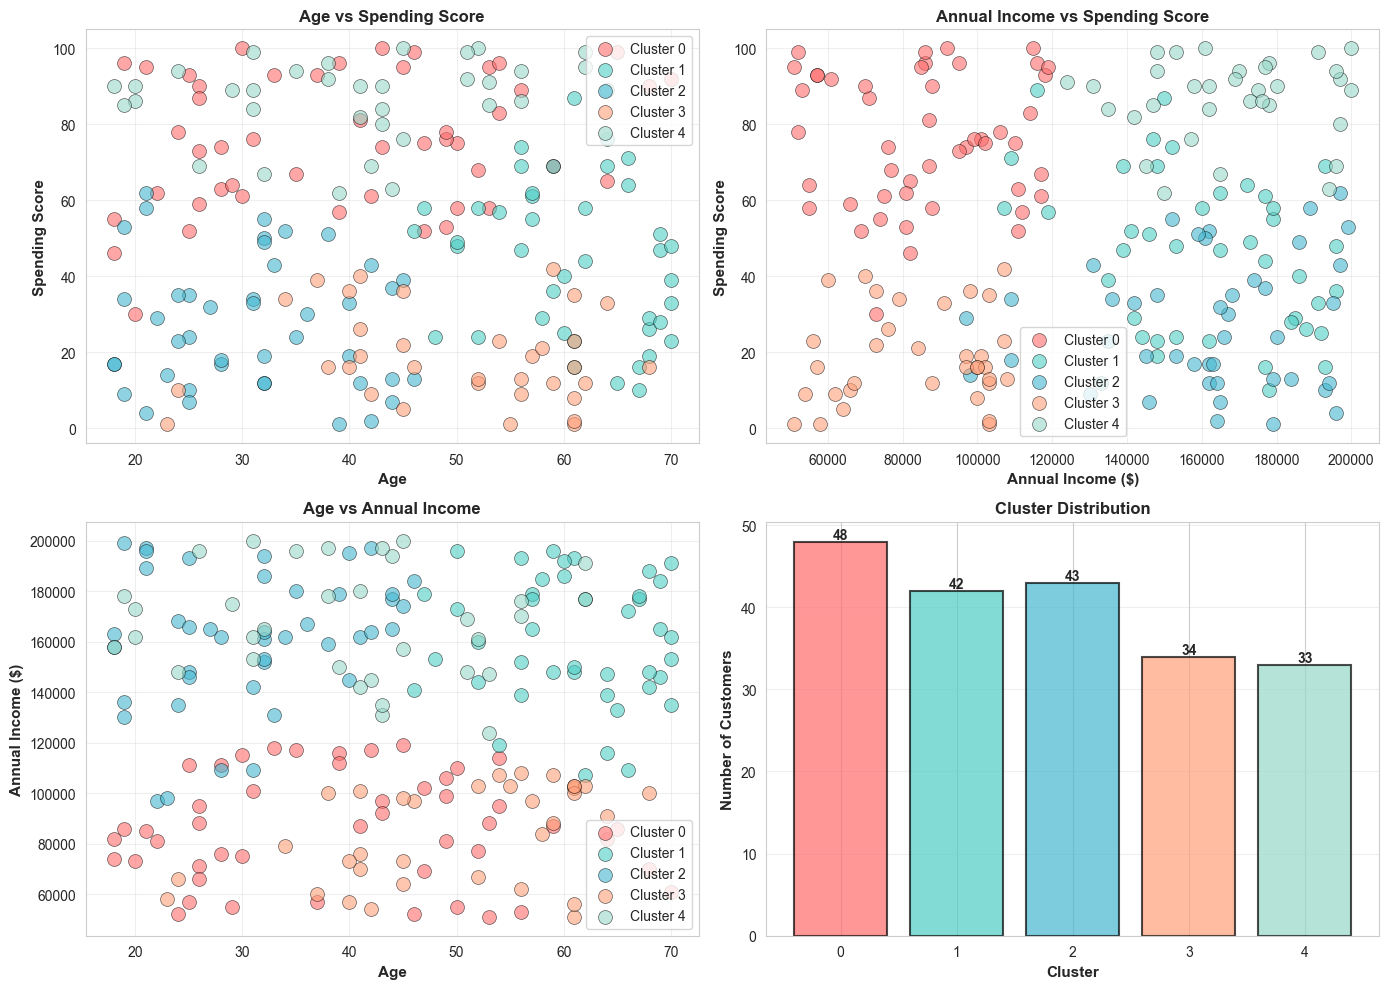

Cluster visualization completed


In [6]:
# Create subplots to visualize clusters from different perspectives
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Color palette for clusters
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8']
cluster_colors = [colors[i] for i in range(n_clusters)]

# Plot 1: Age vs Spending Score
ax1 = axes[0, 0]
for cluster in range(n_clusters):
    cluster_data = df[df['Cluster'] == cluster]
    ax1.scatter(cluster_data['Age'], cluster_data['Spending Score'], 
                c=cluster_colors[cluster], label=f'Cluster {cluster}', 
                s=100, alpha=0.6, edgecolors='black', linewidth=0.5)
ax1.set_xlabel('Age', fontsize=11, fontweight='bold')
ax1.set_ylabel('Spending Score', fontsize=11, fontweight='bold')
ax1.set_title('Age vs Spending Score', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Annual Income vs Spending Score
ax2 = axes[0, 1]
for cluster in range(n_clusters):
    cluster_data = df[df['Cluster'] == cluster]
    ax2.scatter(cluster_data['Annual Income'], cluster_data['Spending Score'], 
                c=cluster_colors[cluster], label=f'Cluster {cluster}', 
                s=100, alpha=0.6, edgecolors='black', linewidth=0.5)
ax2.set_xlabel('Annual Income ($)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Spending Score', fontsize=11, fontweight='bold')
ax2.set_title('Annual Income vs Spending Score', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Age vs Annual Income
ax3 = axes[1, 0]
for cluster in range(n_clusters):
    cluster_data = df[df['Cluster'] == cluster]
    ax3.scatter(cluster_data['Age'], cluster_data['Annual Income'], 
                c=cluster_colors[cluster], label=f'Cluster {cluster}', 
                s=100, alpha=0.6, edgecolors='black', linewidth=0.5)
ax3.set_xlabel('Age', fontsize=11, fontweight='bold')
ax3.set_ylabel('Annual Income ($)', fontsize=11, fontweight='bold')
ax3.set_title('Age vs Annual Income', fontsize=12, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Plot 4: Cluster distribution
ax4 = axes[1, 1]
cluster_counts = df['Cluster'].value_counts().sort_index()
bars = ax4.bar(cluster_counts.index, cluster_counts.values, color=cluster_colors, 
               edgecolor='black', linewidth=1.5, alpha=0.7)
ax4.set_xlabel('Cluster', fontsize=11, fontweight='bold')
ax4.set_ylabel('Number of Customers', fontsize=11, fontweight='bold')
ax4.set_title('Cluster Distribution', fontsize=12, fontweight='bold')
ax4.set_xticks(range(n_clusters))
# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom', fontweight='bold')
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("Cluster visualization completed")

## 6. Display Centroids

Extract and display the cluster centroids, showing the center of each customer segment.

CLUSTER CENTROIDS (Original Scale)
      Age  Annual Income  Spending Score  Cluster
39.666667   85916.666667       75.854167        0
60.833333  160404.761905       45.595238        1
30.906977  161302.325581       27.465116        2
50.000000   84147.058824       18.705882        3
39.818182  167727.272727       86.696970        4


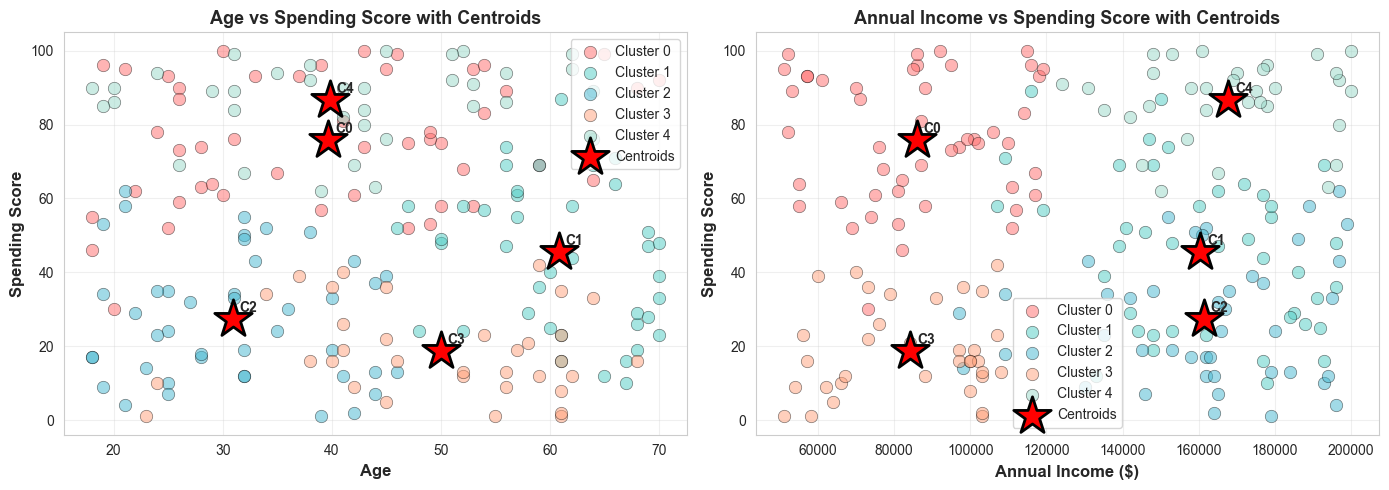


CLUSTER STATISTICS

Cluster 0 (48 customers):
  Age:            39.7 ± 14.4
  Annual Income:  $85,917 ± $21,220
  Spending Score: 75.9 ± 17.3

Cluster 1 (42 customers):
  Age:            60.8 ± 7.0
  Annual Income:  $160,405 ± $24,670
  Spending Score: 45.6 ± 21.0

Cluster 2 (43 customers):
  Age:            30.9 ± 8.6
  Annual Income:  $161,302 ± $26,668
  Spending Score: 27.5 ± 16.9

Cluster 3 (34 customers):
  Age:            50.0 ± 11.5
  Annual Income:  $84,147 ± $19,225
  Spending Score: 18.7 ± 12.1

Cluster 4 (33 customers):
  Age:            39.8 ± 12.4
  Annual Income:  $167,727 ± $21,512
  Spending Score: 86.7 ± 10.7


In [7]:
# Get the centroids in the original (unscaled) space
centroids_scaled = kmeans.cluster_centers_
centroids_original = scaler.inverse_transform(centroids_scaled)

# Create a dataframe of centroids
centroids_df = pd.DataFrame(
    centroids_original,
    columns=['Age', 'Annual Income', 'Spending Score']
)
centroids_df['Cluster'] = range(n_clusters)

print("="*70)
print("CLUSTER CENTROIDS (Original Scale)")
print("="*70)
print(centroids_df.to_string(index=False))
print("="*70)

# Visualize centroids on the plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Age vs Spending Score with Centroids
ax1 = axes[0]
for cluster in range(n_clusters):
    cluster_data = df[df['Cluster'] == cluster]
    ax1.scatter(cluster_data['Age'], cluster_data['Spending Score'], 
                c=cluster_colors[cluster], label=f'Cluster {cluster}', 
                s=80, alpha=0.5, edgecolors='black', linewidth=0.5)

# Plot centroids
ax1.scatter(centroids_df['Age'], centroids_df['Spending Score'], 
            c='red', marker='*', s=800, edgecolors='black', linewidth=2,
            label='Centroids', zorder=5)

# Annotate centroids
for i, row in centroids_df.iterrows():
    ax1.annotate(f'C{i}', (row['Age'], row['Spending Score']),
                xytext=(5, 5), textcoords='offset points', fontweight='bold')

ax1.set_xlabel('Age', fontsize=12, fontweight='bold')
ax1.set_ylabel('Spending Score', fontsize=12, fontweight='bold')
ax1.set_title('Age vs Spending Score with Centroids', fontsize=13, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Annual Income vs Spending Score with Centroids
ax2 = axes[1]
for cluster in range(n_clusters):
    cluster_data = df[df['Cluster'] == cluster]
    ax2.scatter(cluster_data['Annual Income'], cluster_data['Spending Score'], 
                c=cluster_colors[cluster], label=f'Cluster {cluster}', 
                s=80, alpha=0.5, edgecolors='black', linewidth=0.5)

# Plot centroids
ax2.scatter(centroids_df['Annual Income'], centroids_df['Spending Score'], 
            c='red', marker='*', s=800, edgecolors='black', linewidth=2,
            label='Centroids', zorder=5)

# Annotate centroids
for i, row in centroids_df.iterrows():
    ax2.annotate(f'C{i}', (row['Annual Income'], row['Spending Score']),
                xytext=(5, 5), textcoords='offset points', fontweight='bold')

ax2.set_xlabel('Annual Income ($)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Spending Score', fontsize=12, fontweight='bold')
ax2.set_title('Annual Income vs Spending Score with Centroids', fontsize=13, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Display summary statistics for each cluster
print("\n" + "="*70)
print("CLUSTER STATISTICS")
print("="*70)
for cluster in range(n_clusters):
    cluster_data = df[df['Cluster'] == cluster]
    print(f"\nCluster {cluster} ({len(cluster_data)} customers):")
    print(f"  Age:            {cluster_data['Age'].mean():.1f} ± {cluster_data['Age'].std():.1f}")
    print(f"  Annual Income:  ${cluster_data['Annual Income'].mean():,.0f} ± ${cluster_data['Annual Income'].std():,.0f}")
    print(f"  Spending Score: {cluster_data['Spending Score'].mean():.1f} ± {cluster_data['Spending Score'].std():.1f}")